# Module 09 — Topic 03: Seismic Hazard Computation
**DIGIHAZ PhD Course | Completed Exercise**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
import math

## Task 1 — SA(0.5 s) hazard curve and logarithmic interpolation

,SA(0.5s) [g],Annual exceedance rate
0,0.2,0.019500
1,0.4,0.007400
2,0.6,0.003310
3,0.8,0.001650
4,1.0,0.000892
5,1.2,0.000512
6,1.4,0.000308
7,1.6,0.000192
8,1.8,0.000124
9,2.0,0.000082


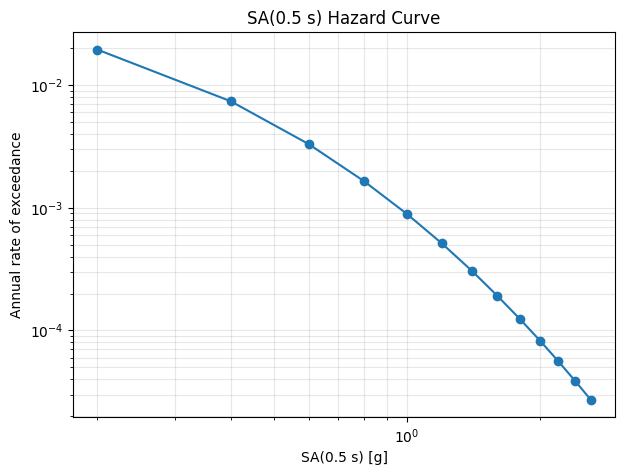

In [2]:
sa=np.array([0.2,0.4,0.6,0.8,1.0,1.2,1.4,1.6,1.8,2.0,2.2,2.4,2.6])
rate=np.array([1.95e-2,7.40e-3,3.31e-3,1.65e-3,8.92e-4,5.12e-4,3.08e-4,1.92e-4,1.24e-4,8.23e-5,5.59e-5,3.87e-5,2.73e-5])
display(pd.DataFrame({'SA(0.5s) [g]':sa,'Annual exceedance rate':rate}))
plt.figure(figsize=(7,5)); plt.loglog(sa,rate,marker='o'); plt.xlabel('SA(0.5 s) [g]'); plt.ylabel('Annual rate of exceedance'); plt.title('SA(0.5 s) Hazard Curve'); plt.grid(True,which='both',alpha=.3); plt.show()

In [3]:
def log_interpolate_im(target,rates,ims):
    for i in range(len(rates)-1):
        if rates[i]>=target>=rates[i+1]:
            x1,x2=rates[i],rates[i+1]; y1,y2=ims[i],ims[i+1]
            return y1*np.exp(np.log(target/x1)*np.log(y2/y1)/np.log(x2/x1))
    raise ValueError('Target outside curve range')
sa_1e3=log_interpolate_im(1e-3,rate,sa); sa_1e4=log_interpolate_im(1e-4,rate,sa)
print(f'SA(0.5s) at 1e-3 /yr = {sa_1e3:.3f} g')
print(f'SA(0.5s) at 1e-4 /yr = {sa_1e4:.3f} g')

SA(0.5s) at 1e-3 /yr = 0.959 g
SA(0.5s) at 1e-4 /yr = 1.902 g


**Task 1 answers:**  $10^{-3}$/yr → **0.959 g**;  $10^{-4}$/yr → **1.902 g**.

## Task 2 — Gutenberg–Richter b-value sensitivity
The handout states ΔM=0.2 but also mentions centre-point steps of ΔM/2=0.1. Using 0.2-wide overlapping bins every 0.1 would double-count probability. This solution therefore uses **contiguous 0.2-magnitude bins** over 5.0–8.5 so that ΣP(M)=1 and the total source rate remains λ(M≥5)=0.05/year. The ambiguity is documented explicitly rather than silently changed.

In [4]:
b1,b2,b3,b4,b5,b6=1.04159,0.91333,-0.0814,-2.92728,0.2812,7.86638
b7,b8,b9,b10=0.08753,0.01527,-0.04189,0.08015
sigma1,sigma2=0.261,0.0994
sigma_log10=np.sqrt(sigma1**2+sigma2**2)
print('Total standard deviation (log10 units)=',sigma_log10)
mmin,mmax,dM=5.0,8.5,0.2
edges=np.arange(mmin,mmax+dM,dM); edges[-1]=mmax; m=(edges[:-1]+edges[1:])/2
targets=np.array([0.01,0.03,0.05,0.1,0.2,0.3,0.5,1.0,1.2])
def F_M(x,b):
    beta=b*np.log(10); return np.clip((1-np.exp(-beta*(x-mmin)))/(1-np.exp(-beta*(mmax-mmin))),0,1)
def hazard_for_b(b):
    pM=F_M(edges[1:],b)-F_M(edges[:-1],b); lambda_M=0.05*pM; Rjb=10.0
    SS,SA,FN,FR=0.0,1.0,0.0,0.0  # Vs30=360 => stiff soil; mechanism unspecified
    mu=b1+b2*m+b3*m**2+(b4+b5*m)*np.log10(np.sqrt(Rjb**2+b6**2))+b7*SS+b8*SA+b9*FN+b10*FR
    median_pga_g=10**mu/981.0
    P=np.vstack([1-norm.cdf((np.log10(x*981.0)-mu)/sigma_log10) for x in targets]).T
    return pM,lambda_M,median_pga_g,(lambda_M[:,None]*P).sum(axis=0)
curves={}
for b in [0.9,1.0,1.1]:
    pM,lambda_M,median_pga_g,curves[b]=hazard_for_b(b)
    print(f'b={b:.1f}: sum P(M)={pM.sum():.6f}, total rate={lambda_M.sum():.6f}/yr')

Total standard deviation (log10 units)= 0.2792872356553375
b=0.9: sum P(M)=1.000000, total rate=0.050000/yr
b=1.0: sum P(M)=1.000000, total rate=0.050000/yr
b=1.1: sum P(M)=1.000000, total rate=0.050000/yr


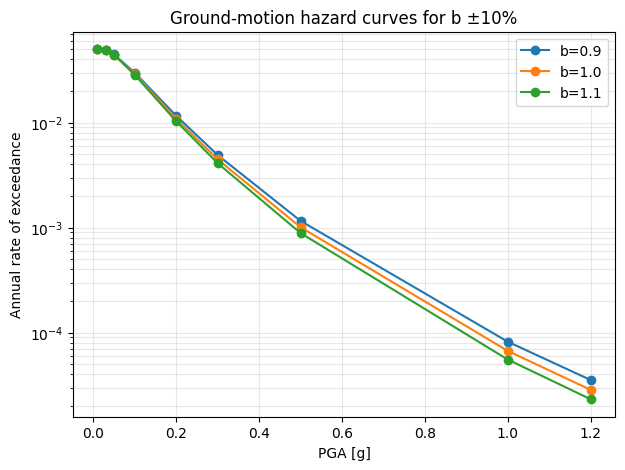

In [5]:
plt.figure(figsize=(7,5))
for b in [0.9,1.0,1.1]: plt.semilogy(targets,curves[b],marker='o',label=f'b={b:.1f}')
plt.xlabel('PGA [g]'); plt.ylabel('Annual rate of exceedance'); plt.title('Ground-motion hazard curves for b ±10%'); plt.legend(); plt.grid(True,which='both',alpha=.3); plt.show()

,PGA_g,Annual_rate,Return_period_years,P_exceed_50yr
0,0.01,0.049993,20.002937,0.917885
1,0.03,0.048788,20.496654,0.912789
2,0.05,0.044421,22.511955,0.891504
3,0.10,0.029143,34.313144,0.767105
4,0.20,0.010921,91.566904,0.420766
5,0.30,0.004471,223.647357,0.200338
6,0.50,0.001009,990.964322,0.049204
7,1.00,0.000067,14932.330529,0.003343
8,1.20,0.000028,35106.063422,0.001423


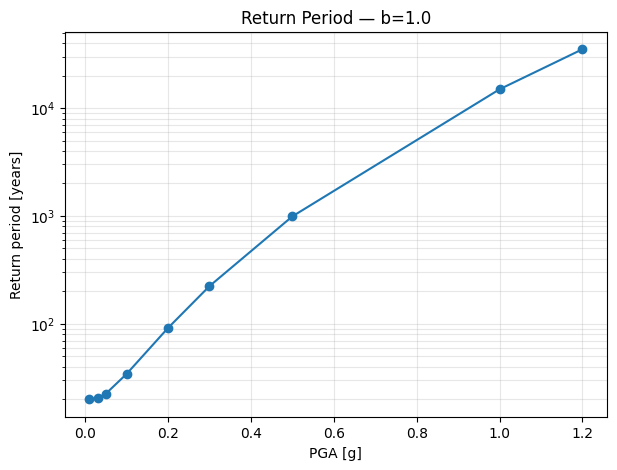

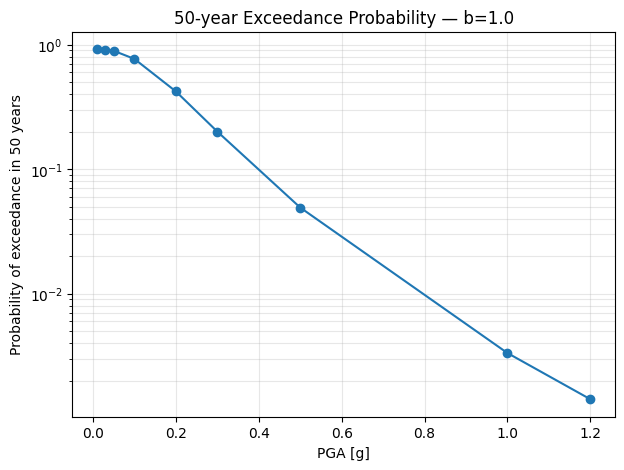

In [6]:
hazard=curves[1.0]; return_period=1/hazard; prob50=1-np.exp(-hazard*50)
summary=pd.DataFrame({'PGA_g':targets,'Annual_rate':hazard,'Return_period_years':return_period,'P_exceed_50yr':prob50}); display(summary)
plt.figure(figsize=(7,5)); plt.semilogy(targets,return_period,marker='o'); plt.xlabel('PGA [g]'); plt.ylabel('Return period [years]'); plt.title('Return Period — b=1.0'); plt.grid(True,which='both',alpha=.3); plt.show()
plt.figure(figsize=(7,5)); plt.semilogy(targets,prob50,marker='o'); plt.xlabel('PGA [g]'); plt.ylabel('Probability of exceedance in 50 years'); plt.title('50-year Exceedance Probability — b=1.0'); plt.grid(True,which='both',alpha=.3); plt.show()

### Interpretation of b
A smaller b-value gives relatively more weight to large-magnitude earthquakes, so **b=0.9** produces the highest exceedance rates, especially at high PGA. Increasing b to **1.1** shifts probability toward smaller earthquakes and reduces the high-motion hazard. At very low PGA the curves converge because almost all source earthquakes exceed the small threshold and the total source rate is fixed at 0.05/year.